In [1]:
# ============================================================
# TRANSPLANT EDA — MIMIC-IV (65+) | Transplant Unit
# Dataset saved from transplant main pipeline BEFORE modeling
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

# ---------------------------
# STYLE
# ---------------------------
sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)

MAIN_PALETTE = "Spectral"
CAT_PALETTE = "Set2"
TIME_PALETTE = "mako"
HEATMAP_PALETTE = "YlOrRd"

# ---------------------------
# HELPERS
# ---------------------------
def los_upper_cap(series, q=0.99):
    return float(series.quantile(q))

def apply_axis_ticks(ax, upper=None, axis="y", n_ticks=8):
    if upper is not None:
        if axis == "y":
            ax.set_ylim(0, upper)
            ax.yaxis.set_major_locator(MaxNLocator(nbins=n_ticks))
        elif axis == "x":
            ax.set_xlim(0, upper)
            ax.xaxis.set_major_locator(MaxNLocator(nbins=n_ticks))
    return ax

def topk_horizontal_barplot(data, col, value_col="LOS_Transplant_hours", k=10, agg="median", title_prefix="Median"):
    if col not in data.columns:
        return

    topk = data[col].value_counts().index[:k]
    sub = data[data[col].isin(topk)].copy()

    summary = (
        sub.groupby(col, as_index=False)[value_col]
        .agg(agg)
        .sort_values(value_col, ascending=True)
    )

    plt.figure(figsize=(11, 6))
    ax = sns.barplot(
        data=summary,
        y=col,
        x=value_col,
        palette=sns.color_palette(MAIN_PALETTE, len(summary))
    )
    ax.set_title(f"{title_prefix} {value_col.replace('_', ' ')} by {col.replace('_', ' ').title()} (Top {k})")
    ax.set_xlabel(f"{title_prefix} {value_col.replace('_', ' ')}")
    ax.set_ylabel(col.replace("_", " ").title())
    apply_axis_ticks(ax, upper=max(summary[value_col]) * 1.15, axis="x", n_ticks=8)
    plt.tight_layout()
    plt.show()

def topk_horizontal_boxplot(data, col, los_cap, k=10):
    if col not in data.columns:
        return

    topk = data[col].value_counts().index[:k]
    sub = data[data[col].isin(topk)].copy()

    order = (
        sub.groupby(col)["LOS_Transplant_hours"]
        .median()
        .sort_values(ascending=True)
        .index
    )

    plt.figure(figsize=(11, 6))
    ax = sns.boxplot(
        data=sub,
        y=col,
        x="LOS_Transplant_hours",
        order=order,
        palette=sns.color_palette(CAT_PALETTE, len(order)),
        showfliers=False
    )
    ax.set_title(f"LOS Distribution by {col.replace('_', ' ').title()} (Top {k})")
    ax.set_xlabel("LOS_Transplant_hours")
    ax.set_ylabel(col.replace("_", " ").title())
    apply_axis_ticks(ax, upper=los_cap, axis="x", n_ticks=8)
    plt.tight_layout()
    plt.show()



In [2]:
# ---------------------------
# LOAD DATASET
# ---------------------------
DATA_PATH = "transplant_dataset_for_eda.parquet"
df = pd.read_parquet(DATA_PATH)

print("Loaded:", df.shape)
display(df.head(3))

assert "LOS_Transplant_hours" in df.columns, "Expected LOS_Transplant_hours in saved dataset."

print(df["LOS_Transplant_hours"].describe(percentiles=[.25, .5, .75, .9, .95, .99]))

df = df[df["LOS_Transplant_hours"].notna()].copy()
df = df[df["LOS_Transplant_hours"] > 0].copy()

df["log_LOS_Transplant"] = np.log1p(df["LOS_Transplant_hours"])
LOS_CAP = los_upper_cap(df["LOS_Transplant_hours"], q=0.99)

print("Visual LOS cap (p99):", LOS_CAP)



Loaded: (6325, 120)


,hadm_id,subject_id,careunit,unit_intime,unit_outtime,LOS_Transplant_hours,gender,anchor_age,admittime,admission_type,admission_location,insurance,marital_status,race,n_transfers,n_careunits,had_ed_transfer,prev_adm_count,days_since_last_adm,infectious,neoplasms,endocrine,blood,mental,nervous,circulatory,respiratory,digestive,genitourinary,skin,muscular,congenital,injury,misc,hours_to_transplant,transplant_entry_hour,transplant_entry_day,transplant_entry_month,admit_hour,admit_day,admit_month,lab_count_Alkaline_Phosphatase,lab_count_Bicarbonate,"lab_count_Bilirubin,_Total",lab_count_Chloride,lab_count_Creatinine,lab_count_Glucose,lab_count_Hemoglobin,lab_count_INR(PT),lab_count_PT,lab_count_PTT,lab_count_Platelet_Count,lab_count_Potassium,lab_count_Sodium,lab_count_Urea_Nitrogen,lab_count_White_Blood_Cells,lab_max_Alkaline_Phosphatase,lab_max_Bicarbonate,"lab_max_Bilirubin,_Total",lab_max_Chloride,lab_max_Creatinine,lab_max_Glucose,lab_max_Hemoglobin,lab_max_INR(PT),lab_max_PT,lab_max_PTT,lab_max_Platelet_Count,lab_max_Potassium,lab_max_Sodium,lab_max_Urea_Nitrogen,lab_max_White_Blood_Cells,lab_mean_Alkaline_Phosphatase,lab_mean_Bicarbonate,"lab_mean_Bilirubin,_Total",lab_mean_Chloride,lab_mean_Creatinine,lab_mean_Glucose,lab_mean_Hemoglobin,lab_mean_INR(PT),lab_mean_PT,lab_mean_PTT,lab_mean_Platelet_Count,lab_mean_Potassium,lab_mean_Sodium,lab_mean_Urea_Nitrogen,lab_mean_White_Blood_Cells,lab_min_Alkaline_Phosphatase,lab_min_Bicarbonate,"lab_min_Bilirubin,_Total",lab_min_Chloride,lab_min_Creatinine,lab_min_Glucose,lab_min_Hemoglobin,lab_min_INR(PT),lab_min_PT,lab_min_PTT,lab_min_Platelet_Count,lab_min_Potassium,lab_min_Sodium,lab_min_Urea_Nitrogen,lab_min_White_Blood_Cells,lab_count_Alkaline_Phosphatase_measured_flag,lab_count_Bicarbonate_measured_flag,"lab_count_Bilirubin,_Total_measured_flag",lab_count_Chloride_measured_flag,lab_count_Creatinine_measured_flag,lab_count_Glucose_measured_flag,lab_count_Hemoglobin_measured_flag,lab_count_INR(PT)_measured_flag,lab_count_PT_measured_flag,lab_count_PTT_measured_flag,lab_count_Platelet_Count_measured_flag,lab_count_Potassium_measured_flag,lab_count_Sodium_measured_flag,lab_count_Urea_Nitrogen_measured_flag,lab_count_White_Blood_Cells_measured_flag,bun_creatinine_ratio,inr_high_flag,bilirubin_high_flag,alp_high_flag
0,29927609,10011352,Transplant,2133-03-15 17:40:33,2133-03-17 19:33:00,49.87,F,65,2133-02-26 23:40:00,OBSERVATION ADMIT,WALK-IN/SELF REFERRAL,Other,MARRIED,WHITE,7,5,1,0,-1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31.0,402.009167,17,6,3,23,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0,0,0
1,20219031,10011427,Transplant,2136-03-21 01:25:00,2136-04-08 16:38:35,172.31,F,69,2136-03-20 23:57:00,EW EMER.,TRANSFER FROM HOSPITAL,Private,MARRIED,WHITE,8,4,1,3,7.222222,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29.0,1.466667,1,2,3,23,1,3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,99.0,16.0,1.5,97.0,4.9,140.0,8.2,1.8,19.9,33.1,52.0,3.0,134.0,82.0,11.0,99.0,16.0,1.5,97.0,4.9,140.0,8.2,1.8,19.9,33.1,52.0,3.0,134.0,82.0,11.0,99.0,16.0,1.5,97.0,4.9,140.0,8.2,1.8,19.9,33.1,52.0,3.0,134.0,82.0,11.0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,16.734694,1,0,0
2,22216667,10011427,Transplant,2136-01-11 22:10:00,2136-02-12 17:08:31,550.27,F,69,2136-01-11 20:04:00,EW EMER.,TRANSFER FROM HOSPITAL,Private,MARRIED,WHITE,4,3,1,1,19.010417,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.0,2.100000,22,2,1,20,2,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,68.0,13.0,1.1,110.0,2.8,110.0,7.0,1.6,17.6,34.3,49.0,4.1,137.0,76.0,4.3,68.0,13.0,1.1,110.0,2.8,110.0,7.0,1.6,17.6,34.3,49.0,4.1,137.0,76.0,4.3,68.0,13.0,1.1,110.0,2.8,110.0,7.0,1.6,17.6,34.3,49.0,4.1,137.0,76.0,4.3,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,27.14285

count    6325.000000
mean      114.877363
std       146.784973
min         0.010000
25%        36.770000
50%        73.830000
75%       141.440000
90%       240.988000
95%       354.864000
99%       710.682000
max      2420.050000
Name: LOS_Transplant_hours, dtype: float64
Visual LOS cap (p99): 710.6820000000004


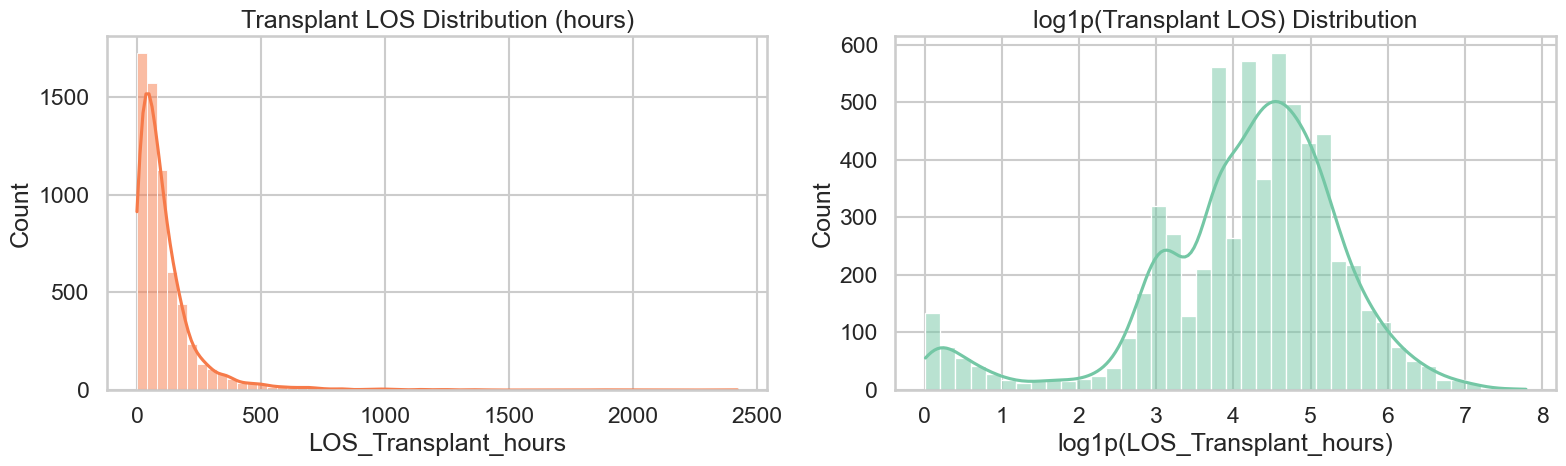

In [3]:
# ============================================================
# 1) TARGET DISTRIBUTION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(
    df["LOS_Transplant_hours"],
    bins=60,
    kde=True,
    color=sns.color_palette(MAIN_PALETTE, 8)[1],
    edgecolor="white",
    ax=axes[0]
)
axes[0].set_title("Transplant LOS Distribution (hours)")
axes[0].set_xlabel("LOS_Transplant_hours")
axes[0].set_ylabel("Count")

sns.histplot(
    df["log_LOS_Transplant"],
    bins=40,
    kde=True,
    color=sns.color_palette(MAIN_PALETTE, 8)[6],
    edgecolor="white",
    ax=axes[1]
)
axes[1].set_title("log1p(Transplant LOS) Distribution")
axes[1].set_xlabel("log1p(LOS_Transplant_hours)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()



In [4]:
# ============================================================
# 2) LOS CLASS DISTRIBUTION
# ============================================================
if "los_class" in df.columns:
    plt.figure(figsize=(6, 5))
    ax = sns.countplot(
        data=df,
        x="los_class",
        palette="Set2"
    )
    ax.set_title("Transplant LOS Class Distribution")
    ax.set_xlabel("LOS Class (0<=2d, 1=2–5d, 2=>5d)")
    ax.set_ylabel("Number of Patients")
    plt.tight_layout()
    plt.show()



C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_36280\3623182291.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


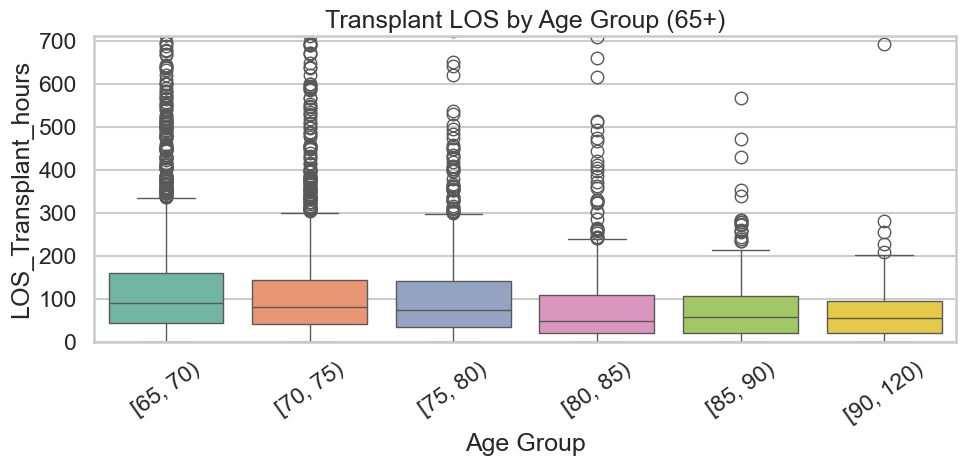

C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_36280\3623182291.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


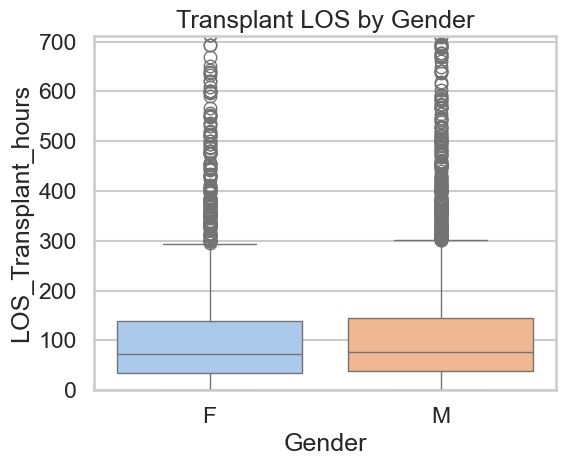

In [5]:
# ============================================================
# 3) DEMOGRAPHICS
# ============================================================
if "anchor_age" in df.columns:
    df["age_group"] = pd.cut(
        df["anchor_age"],
        bins=[65, 70, 75, 80, 85, 90, 120],
        right=False
    )

    plt.figure(figsize=(10, 5))
    ax = sns.boxplot(
        x="age_group",
        y="LOS_Transplant_hours",
        data=df,
        palette="Set2",
        showfliers=True
    )
    ax.set_title("Transplant LOS by Age Group (65+)")
    ax.set_xlabel("Age Group")
    ax.set_ylabel("LOS_Transplant_hours")
    plt.xticks(rotation=35)
    apply_axis_ticks(ax, upper=LOS_CAP, axis="y", n_ticks=8)
    plt.tight_layout()
    plt.show()

if "gender" in df.columns:
    plt.figure(figsize=(6, 5))
    ax = sns.boxplot(
        x="gender",
        y="LOS_Transplant_hours",
        data=df,
        palette="pastel"
    )
    ax.set_title("Transplant LOS by Gender")
    ax.set_xlabel("Gender")
    ax.set_ylabel("LOS_Transplant_hours")
    apply_axis_ticks(ax, upper=LOS_CAP, axis="y", n_ticks=8)
    plt.tight_layout()
    plt.show()



C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_36280\988958732.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


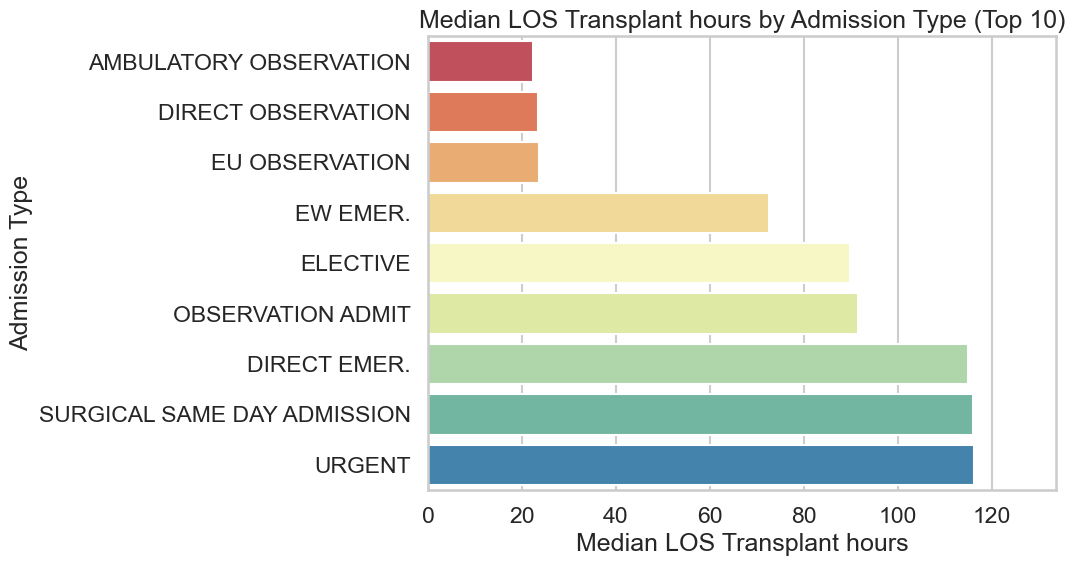

C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_36280\988958732.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


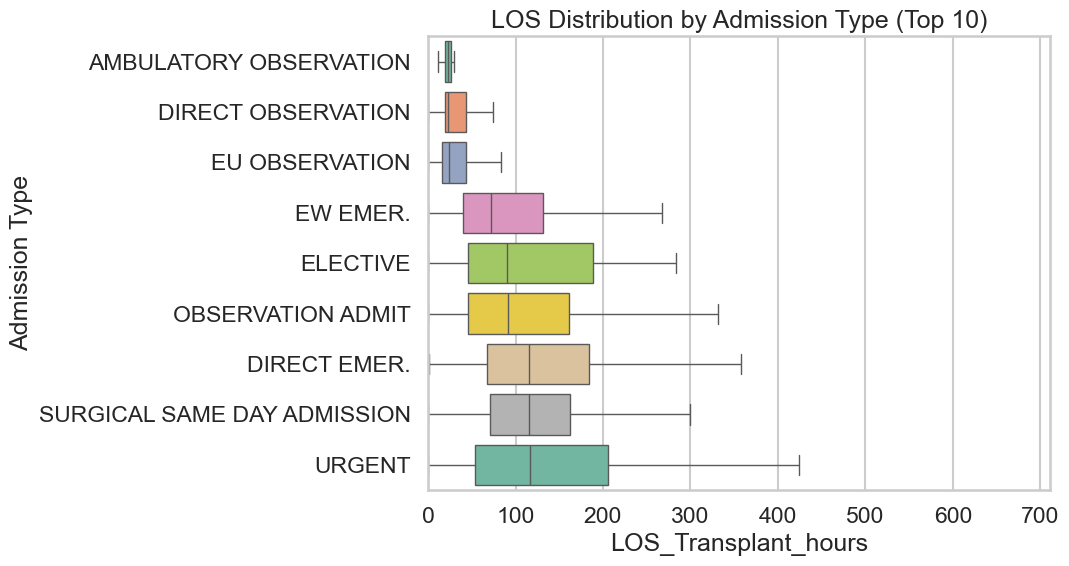

C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_36280\988958732.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


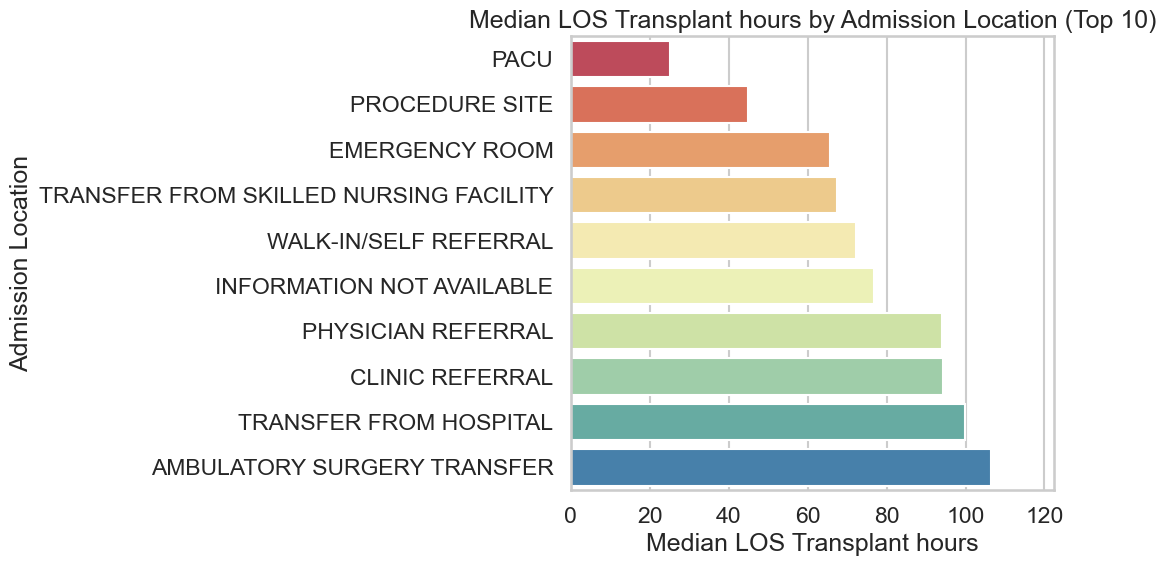

C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_36280\988958732.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


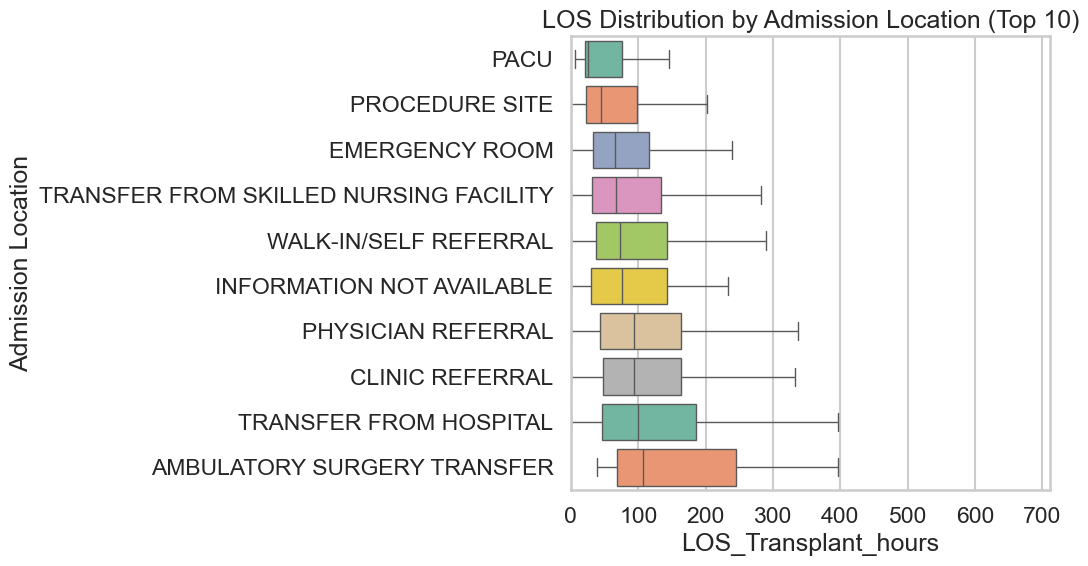

C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_36280\988958732.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


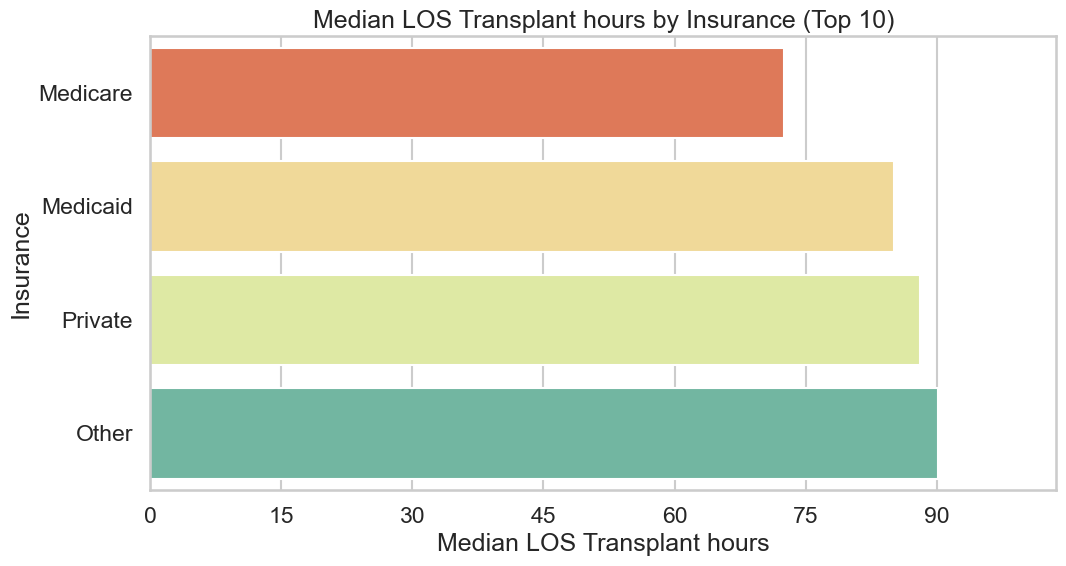

C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_36280\988958732.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


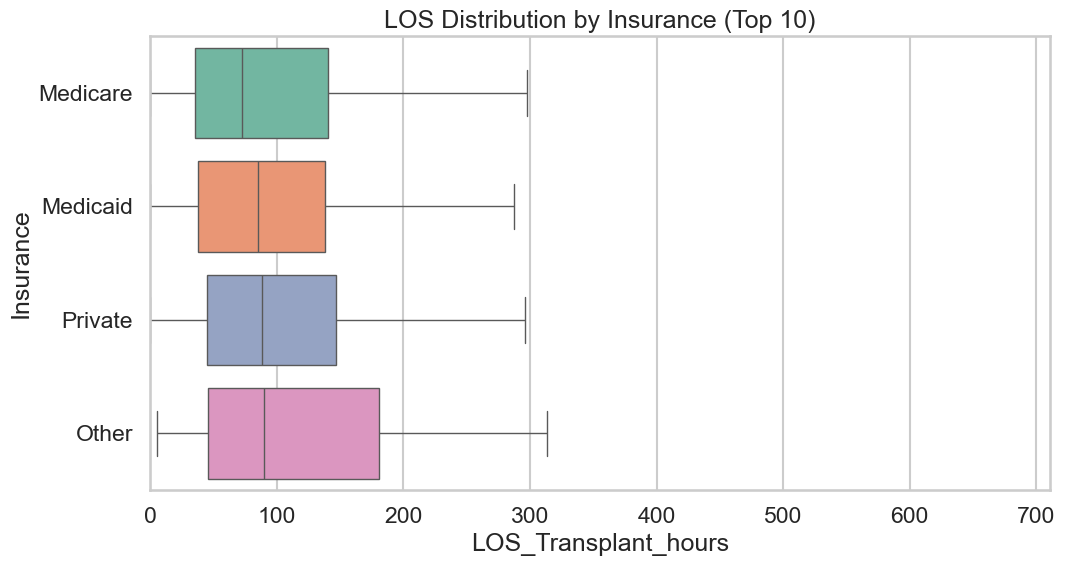

C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_36280\988958732.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


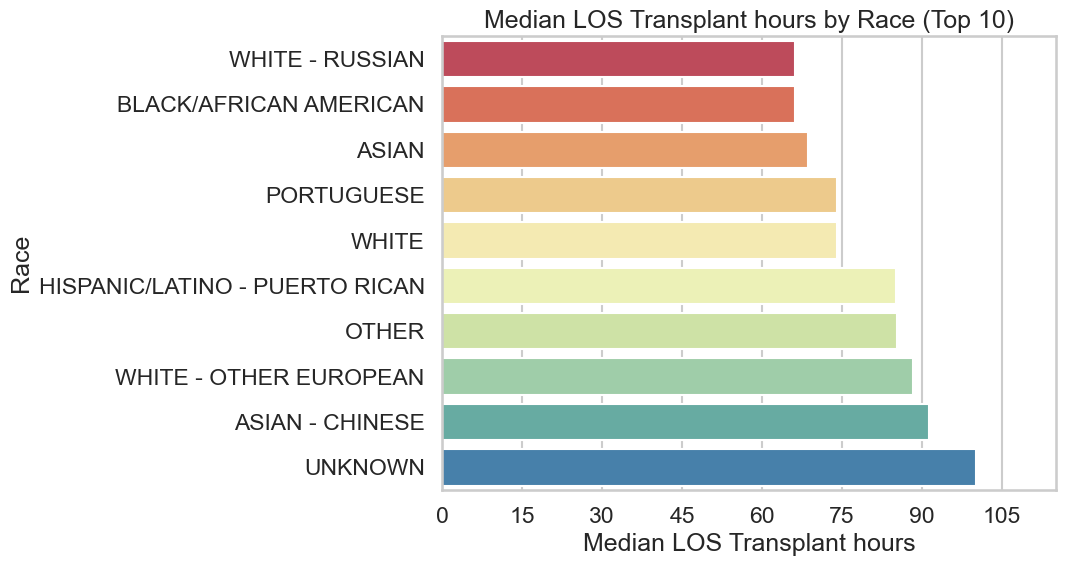

C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_36280\988958732.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


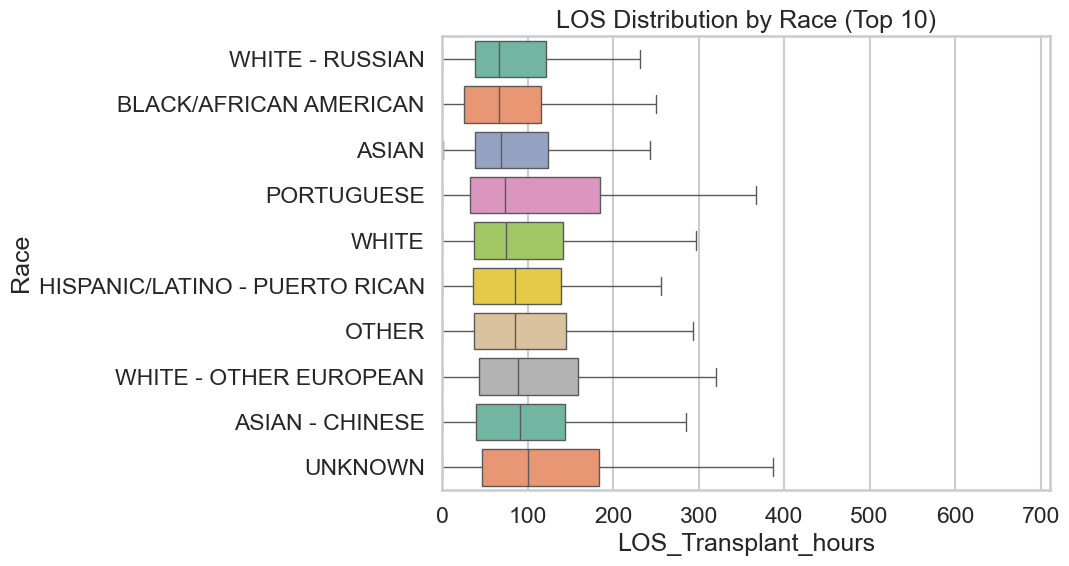

C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_36280\988958732.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


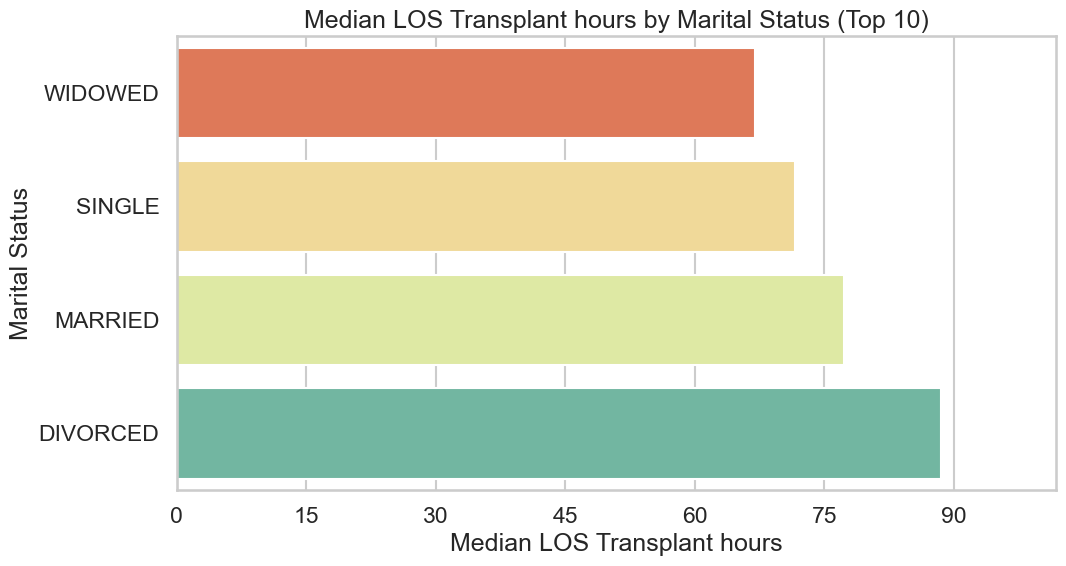

C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_36280\988958732.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


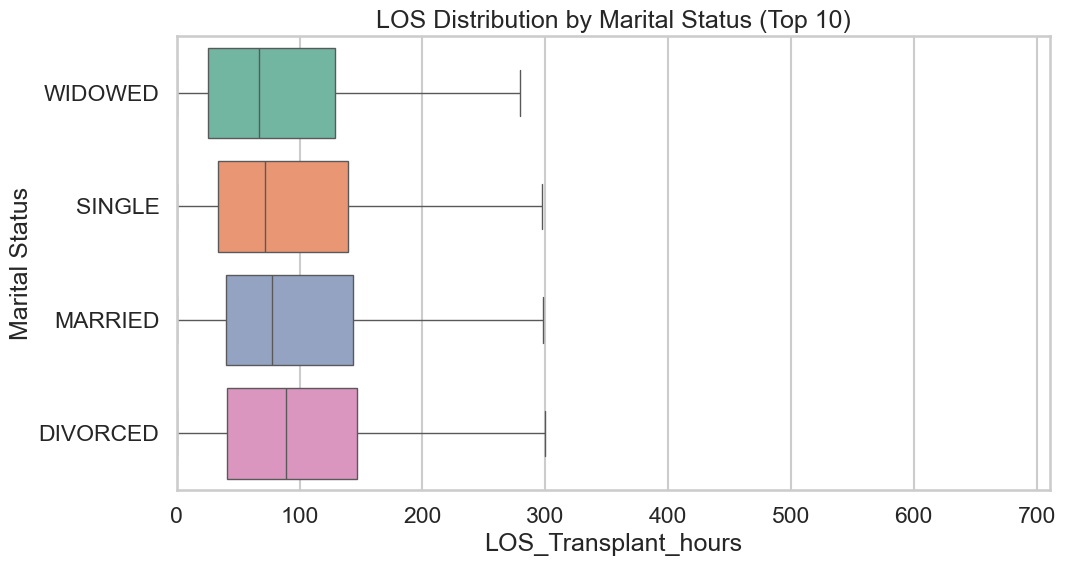

In [6]:
# ============================================================
# 4) ADMISSION CHARACTERISTICS
# ============================================================
for c in ["admission_type", "admission_location", "insurance", "race", "marital_status"]:
    topk_horizontal_barplot(df, c, value_col="LOS_Transplant_hours", k=10, agg="median", title_prefix="Median")
    topk_horizontal_boxplot(df, c, los_cap=LOS_CAP, k=10)



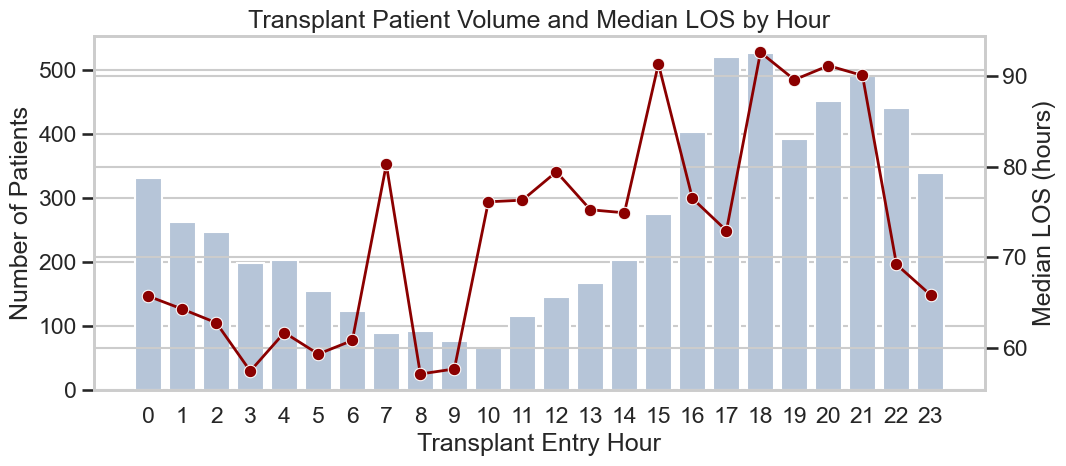

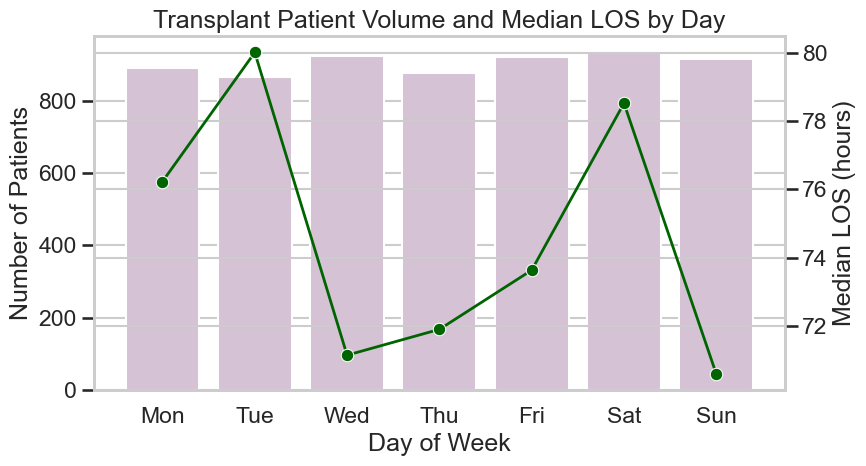

In [7]:
#============================================================
# 5) PATIENT VOLUME + MEDIAN LOS
# ============================================================
if "transplant_entry_hour" in df.columns:
    volume_hour = (
        df.groupby("transplant_entry_hour")
        .agg(
            patient_count=("LOS_Transplant_hours", "count"),
            median_los=("LOS_Transplant_hours", "median")
        )
        .reset_index()
    )

    fig, ax1 = plt.subplots(figsize=(11, 5))

    sns.barplot(
        data=volume_hour,
        x="transplant_entry_hour",
        y="patient_count",
        color="lightsteelblue",
        ax=ax1
    )
    ax1.set_ylabel("Number of Patients")
    ax1.set_xlabel("Transplant Entry Hour")

    ax2 = ax1.twinx()
    sns.lineplot(
        data=volume_hour,
        x="transplant_entry_hour",
        y="median_los",
        color="darkred",
        marker="o",
        linewidth=2,
        ax=ax2
    )
    ax2.set_ylabel("Median LOS (hours)")

    plt.title("Transplant Patient Volume and Median LOS by Hour")
    plt.tight_layout()
    plt.show()

if "transplant_entry_day" in df.columns:
    day_labels = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
    df["transplant_entry_day_name"] = df["transplant_entry_day"].map(day_labels)

    day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

    volume_day = (
        df.groupby("transplant_entry_day_name")
        .agg(
            patient_count=("LOS_Transplant_hours", "count"),
            median_los=("LOS_Transplant_hours", "median")
        )
        .reset_index()
    )

    volume_day["transplant_entry_day_name"] = pd.Categorical(
        volume_day["transplant_entry_day_name"],
        categories=day_order,
        ordered=True
    )
    volume_day = volume_day.sort_values("transplant_entry_day_name")

    fig, ax1 = plt.subplots(figsize=(9, 5))

    sns.barplot(
        data=volume_day,
        x="transplant_entry_day_name",
        y="patient_count",
        color="thistle",
        ax=ax1
    )
    ax1.set_ylabel("Number of Patients")
    ax1.set_xlabel("Day of Week")

    ax2 = ax1.twinx()
    sns.lineplot(
        data=volume_day,
        x="transplant_entry_day_name",
        y="median_los",
        color="darkgreen",
        marker="o",
        linewidth=2,
        ax=ax2
    )
    ax2.set_ylabel("Median LOS (hours)")

    plt.title("Transplant Patient Volume and Median LOS by Day")
    plt.tight_layout()
    plt.show()



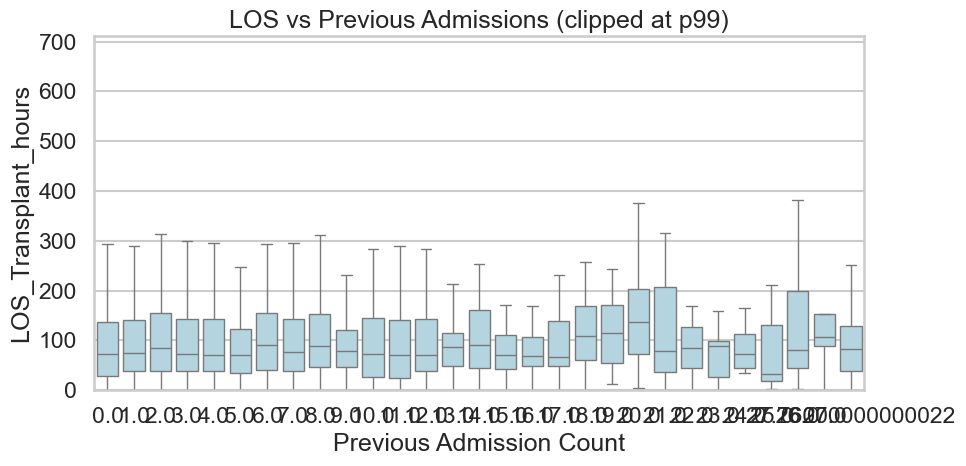

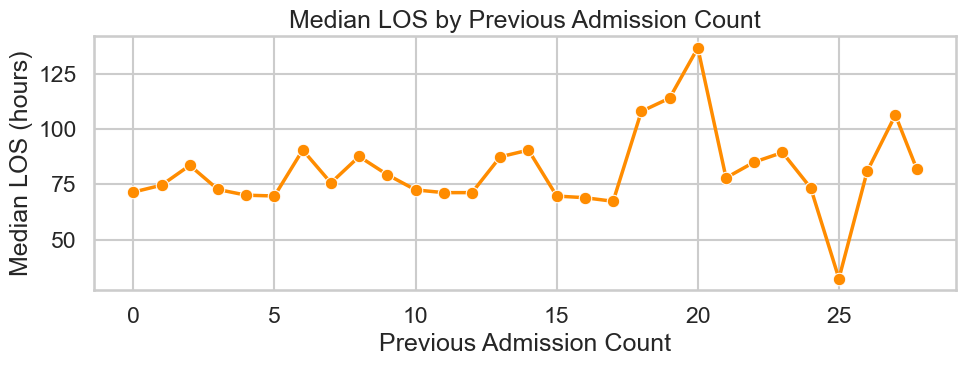

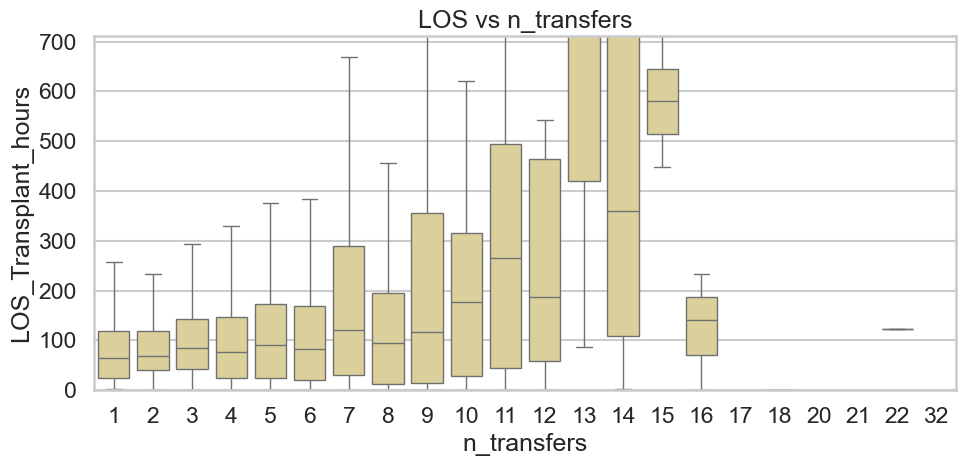

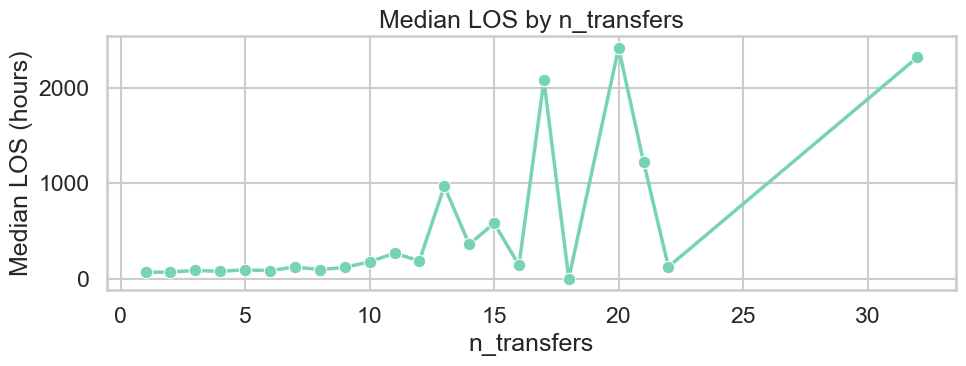

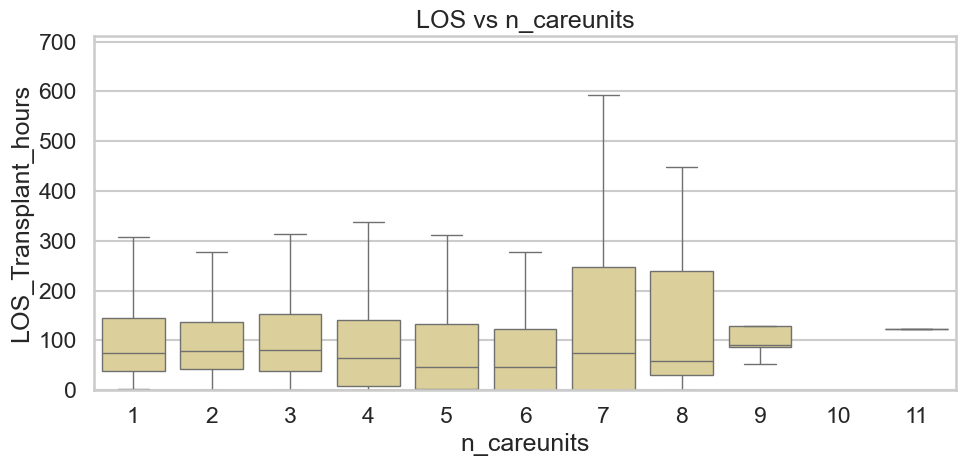

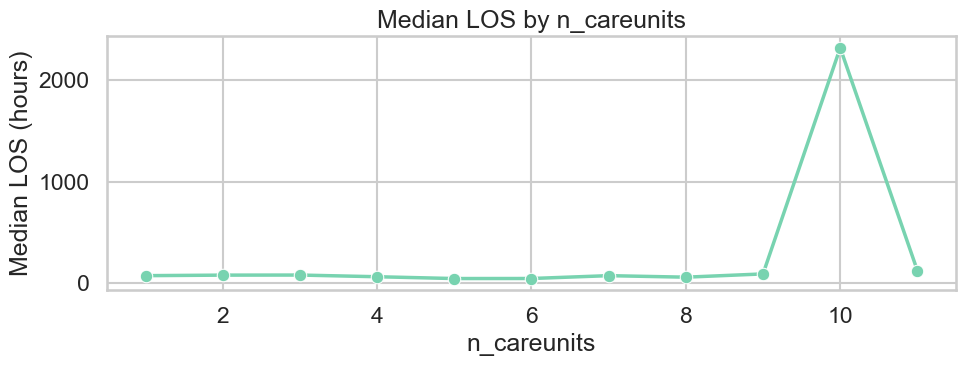

In [8]:
# ============================================================
# 6) OPERATIONAL FEATURES
# ============================================================
if "prev_adm_count" in df.columns:
    sub = df.copy()
    sub["prev_adm_count_clip"] = sub["prev_adm_count"].clip(
        upper=sub["prev_adm_count"].quantile(0.99)
    )

    plt.figure(figsize=(10, 5))
    ax = sns.boxplot(
        x="prev_adm_count_clip",
        y="LOS_Transplant_hours",
        data=sub,
        color="lightblue",
        showfliers=False
    )
    ax.set_title("LOS vs Previous Admissions (clipped at p99)")
    ax.set_xlabel("Previous Admission Count")
    ax.set_ylabel("LOS_Transplant_hours")
    apply_axis_ticks(ax, upper=LOS_CAP, axis="y", n_ticks=8)
    plt.tight_layout()
    plt.show()

    summary = (
        sub.groupby("prev_adm_count_clip", as_index=False)["LOS_Transplant_hours"]
        .median()
    )

    plt.figure(figsize=(10, 4))
    ax = sns.lineplot(
        data=summary,
        x="prev_adm_count_clip",
        y="LOS_Transplant_hours",
        marker="o",
        linewidth=2.5,
        color="darkorange"
    )
    ax.set_title("Median LOS by Previous Admission Count")
    ax.set_xlabel("Previous Admission Count")
    ax.set_ylabel("Median LOS (hours)")
    plt.tight_layout()
    plt.show()

for c, box_color, line_color in [
    ("n_transfers", "#e6d690", "#78d3b0"),
    ("n_careunits", "#e6d690", "#78d3b0")
]:
    if c in df.columns:
        plt.figure(figsize=(10, 5))
        ax = sns.boxplot(
            x=c,
            y="LOS_Transplant_hours",
            data=df,
            color=box_color,
            showfliers=False
        )
        ax.set_title(f"LOS vs {c}")
        ax.set_xlabel(c)
        ax.set_ylabel("LOS_Transplant_hours")
        apply_axis_ticks(ax, upper=LOS_CAP, axis="y", n_ticks=8)
        plt.tight_layout()
        plt.show()

        summary = df.groupby(c, as_index=False)["LOS_Transplant_hours"].median()

        plt.figure(figsize=(10, 4))
        ax = sns.lineplot(
            data=summary,
            x=c,
            y="LOS_Transplant_hours",
            marker="o",
            linewidth=2.5,
            color=line_color
        )
        ax.set_title(f"Median LOS by {c}")
        ax.set_xlabel(c)
        ax.set_ylabel("Median LOS (hours)")
        plt.tight_layout()
        plt.show()



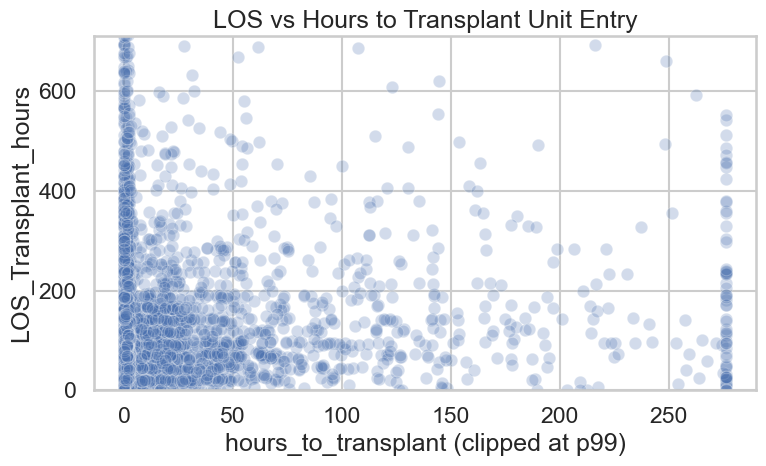

In [9]:
# ============================================================
# 7) TIME TO UNIT ENTRY
# ============================================================
if "hours_to_transplant" in df.columns:
    sub = df.copy()
    sub["hours_to_transplant_clip"] = sub["hours_to_transplant"].clip(
        upper=sub["hours_to_transplant"].quantile(0.99)
    )

    plt.figure(figsize=(8, 5))
    ax = sns.scatterplot(
        x="hours_to_transplant_clip",
        y="LOS_Transplant_hours",
        data=sub,
        alpha=0.25
    )
    ax.set_title("LOS vs Hours to Transplant Unit Entry")
    ax.set_xlabel("hours_to_transplant (clipped at p99)")
    ax.set_ylabel("LOS_Transplant_hours")
    ax.set_ylim(0, LOS_CAP)
    plt.tight_layout()
    plt.show()



C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_36280\1141847840.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


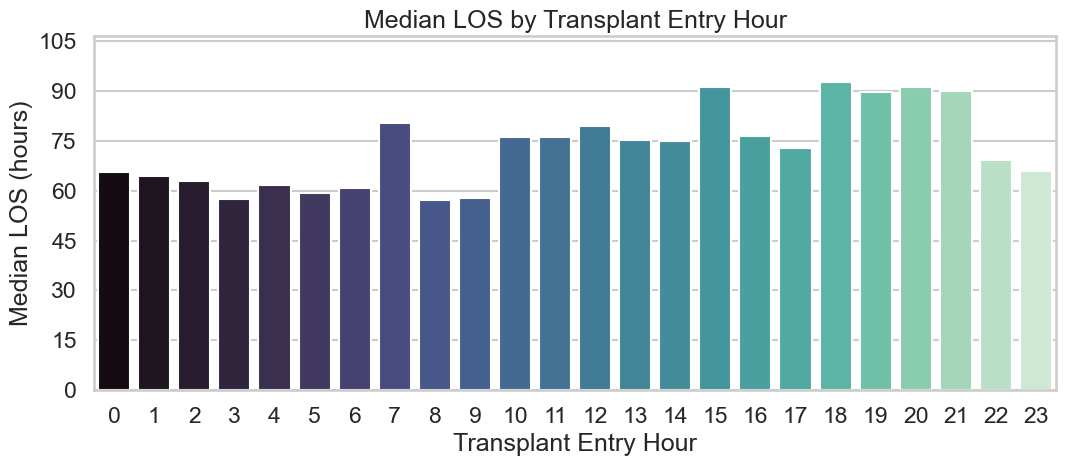

C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_36280\1141847840.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


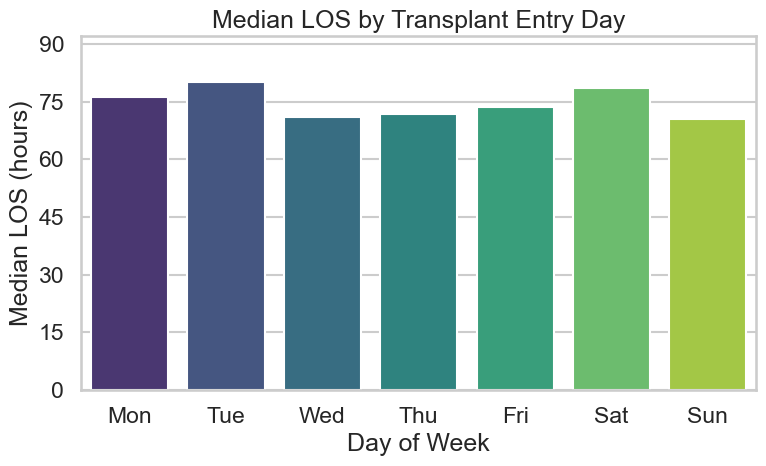

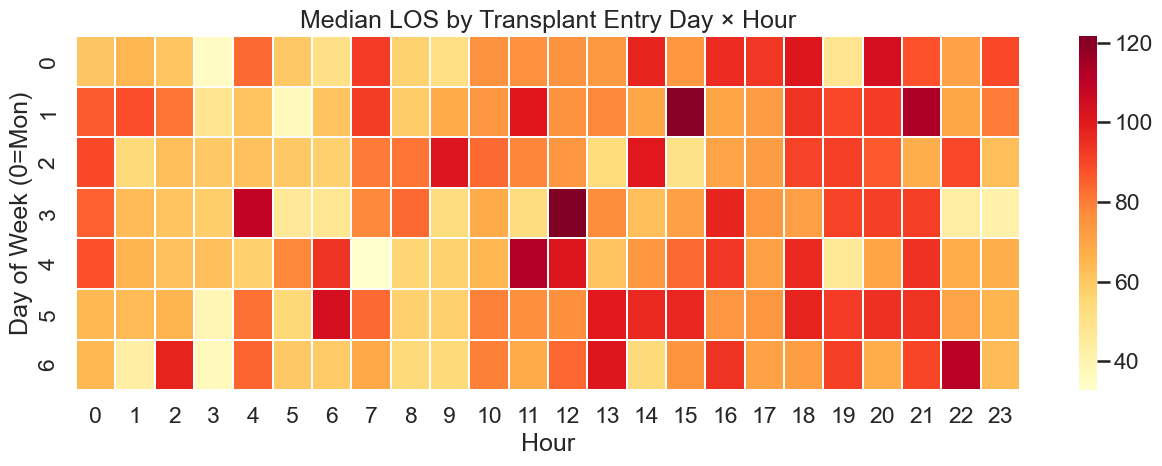

In [10]:
# ============================================================
# 8) TIME PATTERNS
# ============================================================
if "transplant_entry_hour" in df.columns:
    hour_summary = df.groupby("transplant_entry_hour", as_index=False)["LOS_Transplant_hours"].median()

    plt.figure(figsize=(11, 5))
    ax = sns.barplot(
        data=hour_summary,
        x="transplant_entry_hour",
        y="LOS_Transplant_hours",
        palette=sns.color_palette(TIME_PALETTE, len(hour_summary))
    )
    ax.set_title("Median LOS by Transplant Entry Hour")
    ax.set_xlabel("Transplant Entry Hour")
    ax.set_ylabel("Median LOS (hours)")
    apply_axis_ticks(ax, upper=max(hour_summary["LOS_Transplant_hours"]) * 1.15, axis="y", n_ticks=8)
    plt.tight_layout()
    plt.show()

if "transplant_entry_day" in df.columns:
    day_labels = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
    df["transplant_entry_day_name"] = df["transplant_entry_day"].map(day_labels)

    day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    day_summary = (
        df.groupby("transplant_entry_day_name", as_index=False)["LOS_Transplant_hours"]
        .median()
    )
    day_summary["transplant_entry_day_name"] = pd.Categorical(
        day_summary["transplant_entry_day_name"], categories=day_order, ordered=True
    )
    day_summary = day_summary.sort_values("transplant_entry_day_name")

    plt.figure(figsize=(8, 5))
    ax = sns.barplot(
        data=day_summary,
        x="transplant_entry_day_name",
        y="LOS_Transplant_hours",
        palette="viridis"
    )
    ax.set_title("Median LOS by Transplant Entry Day")
    ax.set_xlabel("Day of Week")
    ax.set_ylabel("Median LOS (hours)")
    apply_axis_ticks(ax, upper=max(day_summary["LOS_Transplant_hours"]) * 1.15, axis="y", n_ticks=8)
    plt.tight_layout()
    plt.show()

if "transplant_entry_day" in df.columns and "transplant_entry_hour" in df.columns:
    pivot = df.pivot_table(
        values="LOS_Transplant_hours",
        index="transplant_entry_day",
        columns="transplant_entry_hour",
        aggfunc="median"
    )

    plt.figure(figsize=(13, 5))
    sns.heatmap(
        pivot,
        cmap=HEATMAP_PALETTE,
        annot=False,
        linewidths=0.3
    )
    plt.title("Median LOS by Transplant Entry Day × Hour")
    plt.xlabel("Hour")
    plt.ylabel("Day of Week (0=Mon)")
    plt.tight_layout()
    plt.show()



C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_36280\3199842146.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


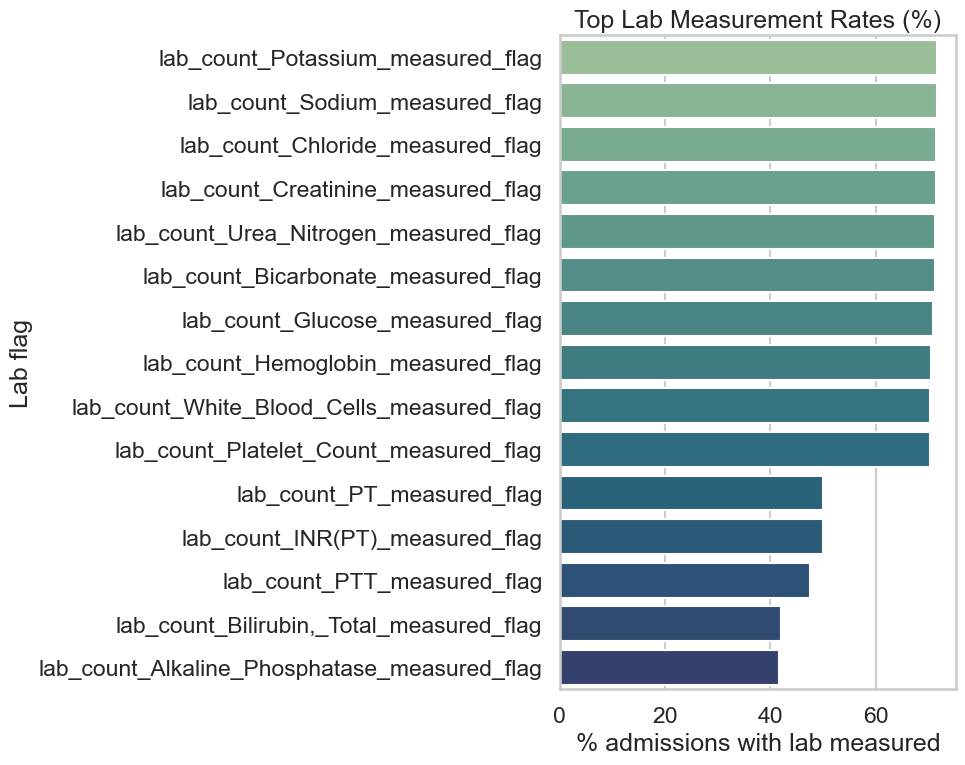

C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_36280\3199842146.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


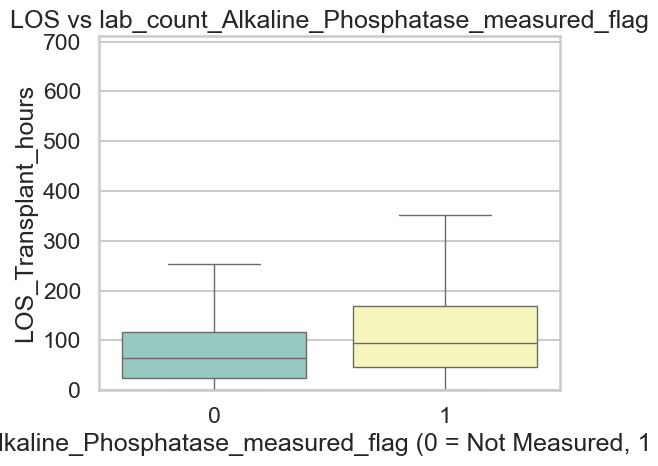

C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_36280\3199842146.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


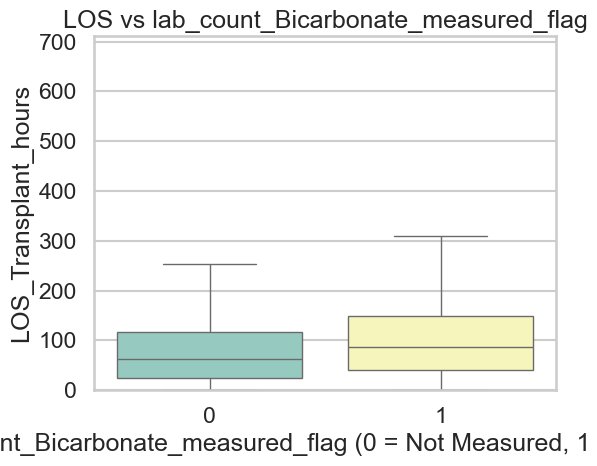

C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_36280\3199842146.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


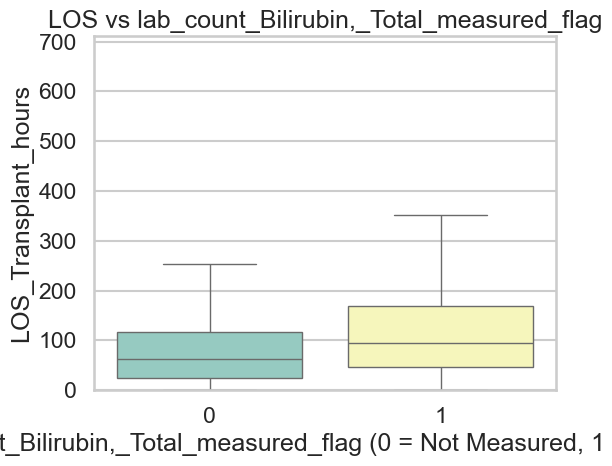

C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_36280\3199842146.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


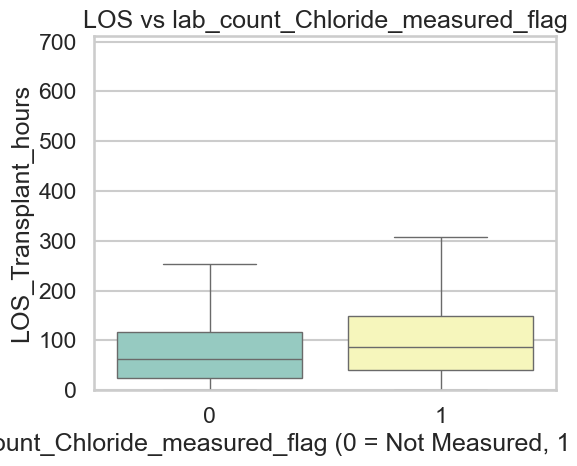

C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_36280\3199842146.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


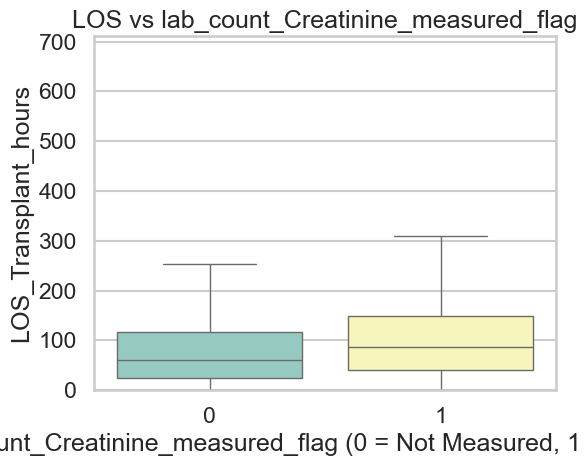

C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_36280\3199842146.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


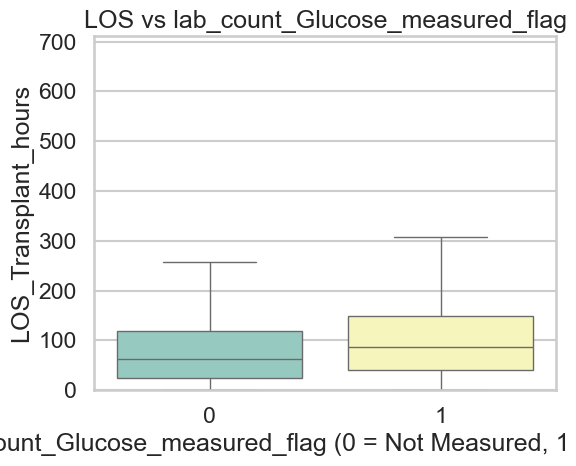

In [11]:
# ============================================================
# 9) LAB MEASUREMENT FLAGS
# ============================================================
measured_flag_cols = [c for c in df.columns if c.endswith("_measured_flag")]

if measured_flag_cols:
    rates = (
        df[measured_flag_cols]
        .mean(numeric_only=True)
        .sort_values(ascending=False)
        .mul(100)
        .round(1)
        .head(20)
    )

    rate_df = rates.reset_index()
    rate_df.columns = ["lab_flag", "pct_measured"]

    plt.figure(figsize=(10, 8))
    ax = sns.barplot(
        data=rate_df,
        y="lab_flag",
        x="pct_measured",
        palette="crest"
    )
    ax.set_title("Top Lab Measurement Rates (%)")
    ax.set_xlabel("% admissions with lab measured")
    ax.set_ylabel("Lab flag")
    plt.tight_layout()
    plt.show()

for flag in measured_flag_cols[:6]:
    plt.figure(figsize=(6, 5))
    ax = sns.boxplot(
        x=flag,
        y="LOS_Transplant_hours",
        data=df,
        palette="Set3",
        showfliers=False
    )
    ax.set_title(f"LOS vs {flag}")
    ax.set_xlabel(f"{flag} (0 = Not Measured, 1 = Measured)")
    ax.set_ylabel("LOS_Transplant_hours")
    apply_axis_ticks(ax, upper=LOS_CAP, axis="y", n_ticks=8)
    plt.tight_layout()
    plt.show()



C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_36280\857332068.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub.groupby("lab_bin", as_index=False)["LOS_Transplant_hours"]
C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_36280\857332068.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


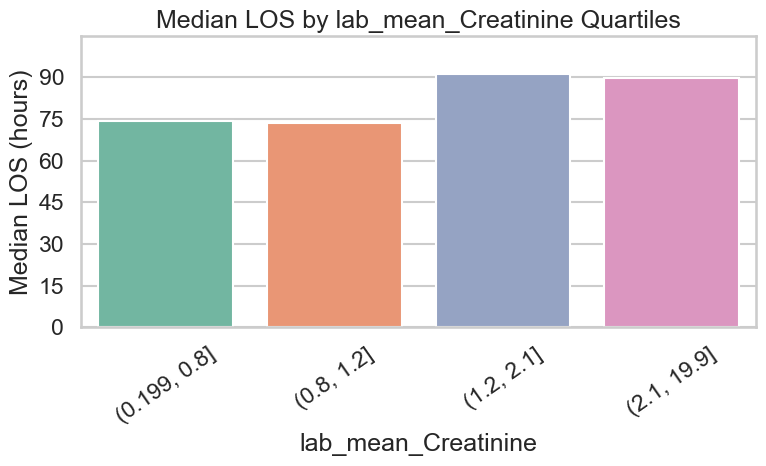

C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_36280\857332068.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub.groupby("lab_bin", as_index=False)["LOS_Transplant_hours"]
C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_36280\857332068.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


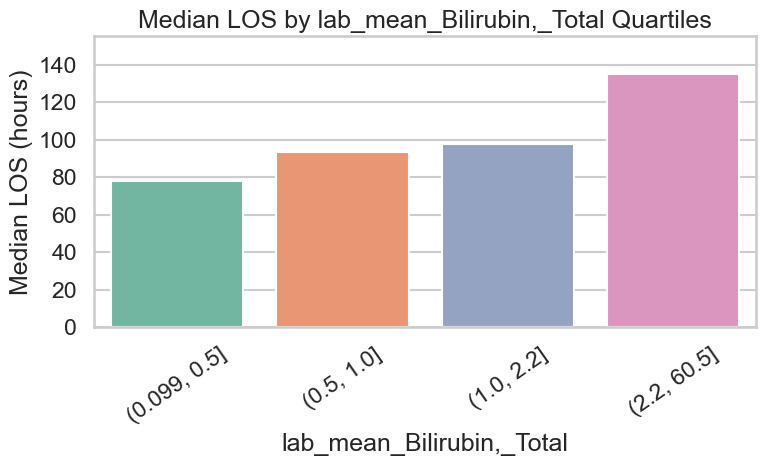

C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_36280\857332068.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub.groupby("lab_bin", as_index=False)["LOS_Transplant_hours"]
C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_36280\857332068.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


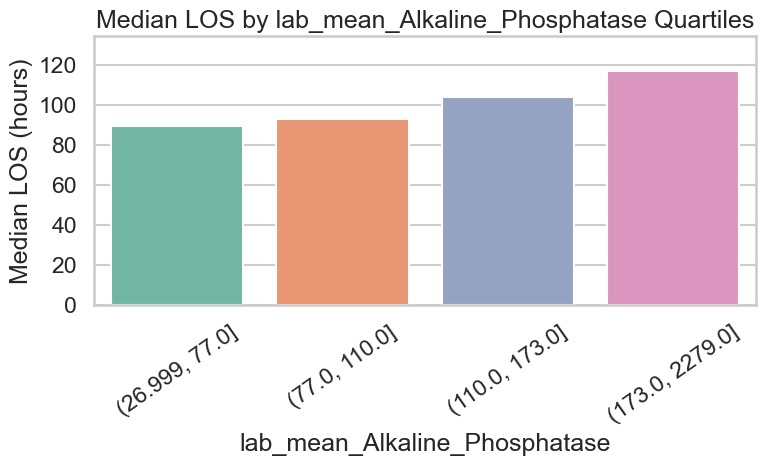

In [12]:
# ============================================================
# 10) TRANSPLANT-SPECIFIC LAB EFFECTS
# ============================================================
for lab_col in [
    "lab_mean_Creatinine",
    "lab_mean_Bilirubin,_Total",
    "lab_mean_AST_(SGOT)",
    "lab_mean_ALT_(SGPT)",
    "lab_mean_Alkaline_Phosphatase"
]:
    if lab_col in df.columns:
        sub = df[[lab_col, "LOS_Transplant_hours"]].dropna().copy()

        if len(sub) > 0:
            sub["lab_bin"] = pd.qcut(sub[lab_col], q=4, duplicates="drop")

            summary = (
                sub.groupby("lab_bin", as_index=False)["LOS_Transplant_hours"]
                .median()
            )

            plt.figure(figsize=(8, 5))
            ax = sns.barplot(
                data=summary,
                x="lab_bin",
                y="LOS_Transplant_hours",
                palette="Set2"
            )
            ax.set_title(f"Median LOS by {lab_col} Quartiles")
            ax.set_xlabel(lab_col)
            ax.set_ylabel("Median LOS (hours)")
            plt.xticks(rotation=35)
            apply_axis_ticks(ax, upper=max(summary["LOS_Transplant_hours"]) * 1.15, axis="y", n_ticks=8)
            plt.tight_layout()
            plt.show()



C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_36280\968841775.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub.groupby("feat_bin", as_index=False)["LOS_Transplant_hours"]
C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_36280\968841775.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


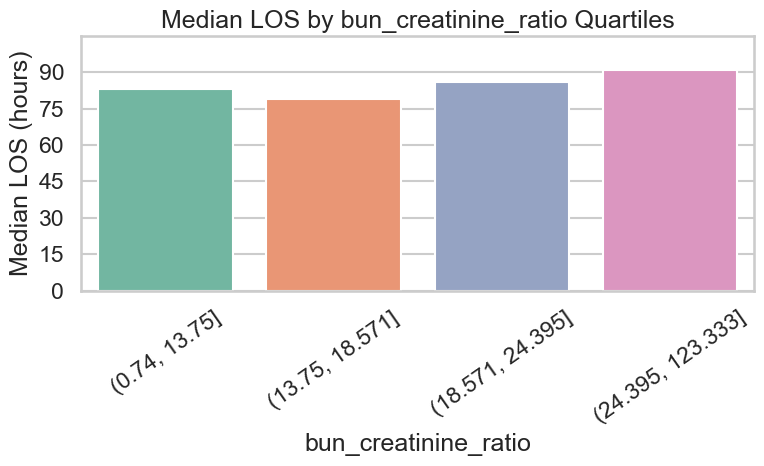

C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_36280\968841775.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


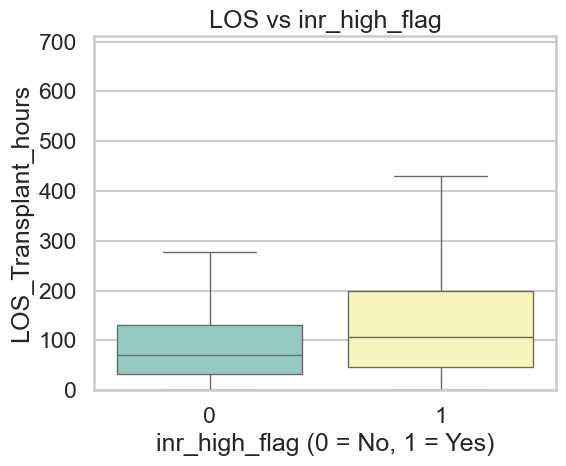

C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_36280\968841775.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


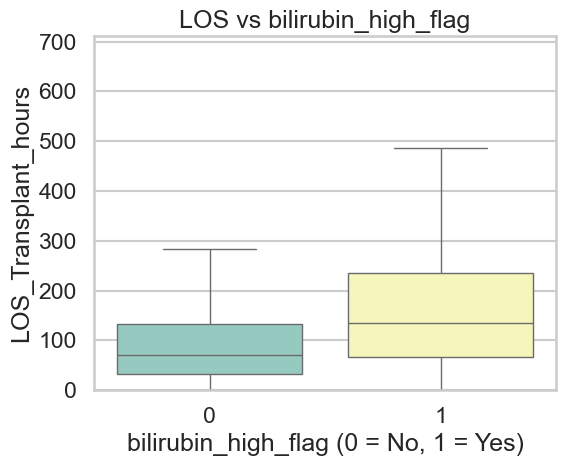

C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_36280\968841775.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


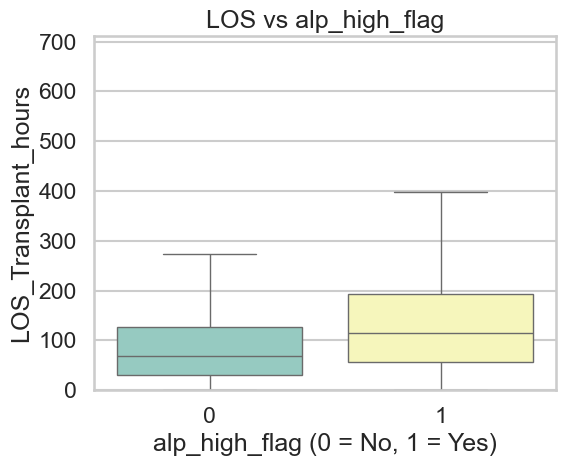


Transplant EDA complete ✅


In [13]:
# ============================================================
# 11) TRANSPLANT DERIVED FEATURES
# ============================================================
for feat in ["ast_alt_ratio", "bun_creatinine_ratio"]:
    if feat in df.columns:
        sub = df[[feat, "LOS_Transplant_hours"]].dropna().copy()

        if len(sub) > 0:
            sub["feat_bin"] = pd.qcut(sub[feat], q=4, duplicates="drop")

            summary = (
                sub.groupby("feat_bin", as_index=False)["LOS_Transplant_hours"]
                .median()
            )

            plt.figure(figsize=(8, 5))
            ax = sns.barplot(
                data=summary,
                x="feat_bin",
                y="LOS_Transplant_hours",
                palette="Set2"
            )
            ax.set_title(f"Median LOS by {feat} Quartiles")
            ax.set_xlabel(feat)
            ax.set_ylabel("Median LOS (hours)")
            plt.xticks(rotation=35)
            apply_axis_ticks(ax, upper=max(summary["LOS_Transplant_hours"]) * 1.15, axis="y", n_ticks=8)
            plt.tight_layout()
            plt.show()

for flag_col in ["inr_high_flag", "bilirubin_high_flag", "alp_high_flag"]:
    if flag_col in df.columns:
        plt.figure(figsize=(6, 5))
        ax = sns.boxplot(
            x=flag_col,
            y="LOS_Transplant_hours",
            data=df,
            palette="Set3",
            showfliers=False
        )
        ax.set_title(f"LOS vs {flag_col}")
        ax.set_xlabel(f"{flag_col} (0 = No, 1 = Yes)")
        ax.set_ylabel("LOS_Transplant_hours")
        apply_axis_ticks(ax, upper=LOS_CAP, axis="y", n_ticks=8)
        plt.tight_layout()
        plt.show()


print("\nTransplant EDA complete ✅")

C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_36280\3029789407.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


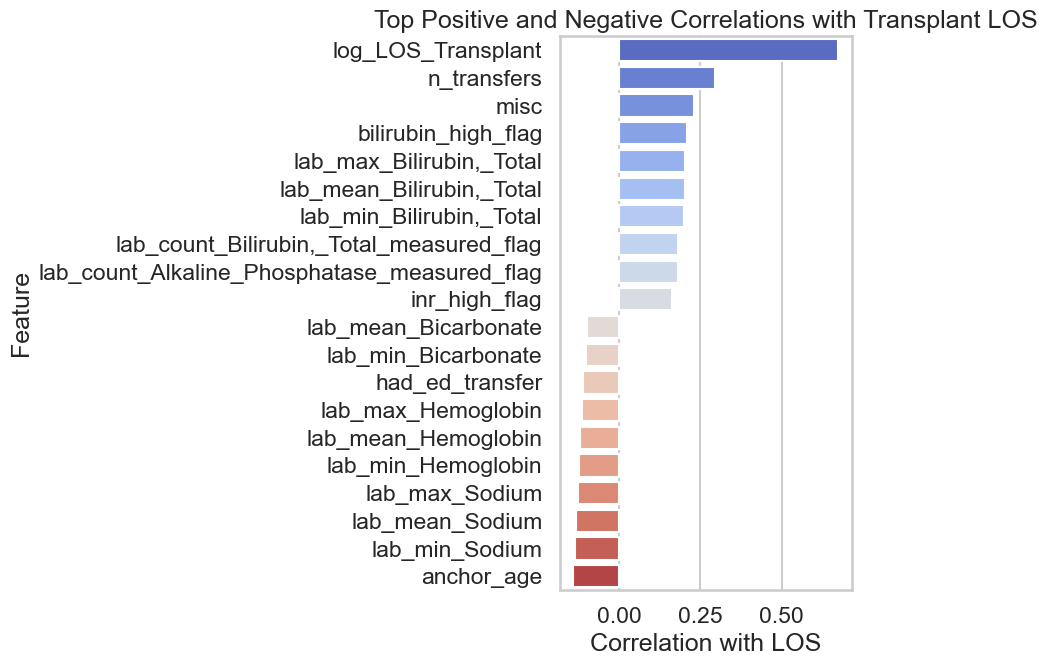

In [14]:
# ============================================================
# 12) FEATURE CORRELATION WITH LOS
# ============================================================
num_df = df.select_dtypes(include=[np.number]).copy()

corr_target = (
    num_df.corr()["LOS_Transplant_hours"]
    .drop("LOS_Transplant_hours")
    .sort_values(ascending=False)
)

top_corr = pd.concat([
    corr_target.head(10),
    corr_target.tail(10)
])

plt.figure(figsize=(9, 7))
ax = sns.barplot(
    x=top_corr.values,
    y=top_corr.index,
    palette="coolwarm"
)
ax.set_title("Top Positive and Negative Correlations with Transplant LOS")
ax.set_xlabel("Correlation with LOS")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()
